# Generating Mock Data

## imports

In [1]:
# Without the following work-around line, pytorch is incompatible with agama
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"


import agama
import numpy as np
import torch
from sbi.inference import NLE
from sbi.utils import BoxUniform
from sbi.inference import likelihood_estimator_based_potential
from sbi.analysis import conditional_pairplot

/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Set units
agama.setUnits(mass=1, length=1, velocity=1)

def make_potential(p_0: float, r_s: float, gamma: float) -> agama.Potential:
    """
    Makes potential according to GNFW profile
    
    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope

    Preconditions:
    -   0 <= gamma <= 1
    """

    # Based on GNFW Profile
    param = {
        "type": "Spheroid", 
        "densityNorm": p_0,
        "scaleRadius": r_s,
        "gamma": gamma,
        "beta": 3,
        "alpha": 1
    }

    return agama.Potential(param)

def make_density(r_star: float):
    """
    Creates stellar density distribution according to the 3D Plummer Profile

    - r_star: scale length
    """

    # Based on Plummer profile
    param = {
        "type": "Spheroid",
        "mass": 1,
        "scaleRadius": r_star,
        "gamma": 0,
        "beta": 5,
        "alpha": 2,
    }
    
    return agama.Density(param)


def generate_galaxy(p_0: float, r_s: float, gamma: float, r_star: float, r_a: float):
    """
    Generate the galaxy model given theta

    - p_0: density normalization
    - r_s: scale radius
    - gamma: inner slope
    - r_star: scale length
    - r_a: the radius of transition from isotropic velocity orbits at small radii to radially biased orbits at larger radii (anisotropy radius).

    """

    pot = make_potential(p_0, r_s, gamma)

    df = agama.DistributionFunction(
        type = "QuasiSpherical",
        potential = pot,
        density = make_density(r_star),
        # anisType = "OsipkovMerritt",
        r_a = r_a
    )

    return agama.GalaxyModel(pot, df)

def transform_params(theta: torch.Tensor) -> torch.Tensor:
    """
    transform parameters into correct for generate_galaxy

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """


    p_0 = 10 ** theta[:,0]
    r_s = 10 ** theta[:,1]
    gamma = theta[:,2]
    r_star = theta[:,3] * r_s
    r_a = theta[:,4] * r_star

    return torch.stack([p_0, r_s, gamma, r_star, r_a], dim=1)


def generate_galaxy_bunch(theta: torch.Tensor) -> torch.Tensor:
    """
    Generate the galaxy model given theta

    returns a vector (of 1 star) for each theta

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """
    transformed_theta = transform_params(theta)
    
    samples_np = np.vstack([generate_galaxy(*row.tolist()).sample(1)[0][0] for row in transformed_theta])

    return torch.from_numpy(samples_np).to(torch.float32)  # sbi requires float 32


def generate_galaxy_complex(theta: torch.Tensor, n_stars:int) -> torch.Tensor:
    """
    Generate the galaxy model with multiple stars given theta 

    returns a matrix of stars for each theta

    - theta: tensor of sampled theta with columns \
        log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
    """
    transformed_theta = transform_params(theta)
    
    samples_np = np.vstack([[generate_galaxy(*row.tolist()).sample(n_stars)[0]] for row in transformed_theta])

    return torch.from_numpy(samples_np).to(torch.float32)  # sbi requires float 32


In [ ]:
t = torch.tensor([[6, 0, 0.5, 0.5, 1],
                  [5.9, 0.1, 0.6, 0.6, 1]])
generate_galaxy_complex(t, n_stars=5)

In [ ]:
transformed_theta = transform_params(t)
n_stars = 2
samples_np = np.vstack([generate_galaxy(*row.tolist()).sample(n_stars)[0] for row in transformed_theta])

samples_np

torch.from_numpy(samples_np).to(torch.float32)

## Training

In [3]:
agama.setRandomSeed(13)
torch.manual_seed(13)

### Proof of concept

In [4]:
# Check table 1 from Nguyen et al. for prior values

# Create the prior boundary in following order: log(p_0), log(r_s), gamma, r_star/r_s, r_a/r_star
def generate_prior(n_samples: int):
    """
    Generate the thetas and x from uniform distribution of the prior
    """
    

    low = torch.tensor([5, -1, -1, 0.2, 0.5])
    high = torch.tensor([8, 0.7, 2, 1, 2])

    # Create uniform distribution
    prior = BoxUniform(low=low, high=high)

    # Sample from said distribution
    theta = prior.sample((n_samples,))

    # Generate the data
    x = generate_galaxy_bunch(theta)

    return prior, theta, x

prior, theta, x = generate_prior(100)

#### load preloaded data

In [ ]:
import pandas as pd
theta = pd.read_csv("./csv/theta.csv")
x = pd.read_csv("./csv/x.csv")

In [ ]:
pd.read_csv("./csv/x.csv")

In [ ]:
x = torch.from_numpy(pd.read_csv("./csv/x.csv", header=None).to_numpy()).to(torch.float32)
theta = torch.from_numpy(pd.read_csv("./csv/theta.csv", header=None).to_numpy()).to(torch.float32)


#### train

In [5]:
# Set up and train model
inference = NLE(prior=prior)
likelihood_estimator = inference.append_simulations(theta, x).train()

/Users/andyyu/Documents/Python/SUDS/suds/lib/python3.11/site-packages/sbi/inference/trainers/base.py:296: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2, 3, 4, 5] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 220 epochs.

In [ ]:
test_theta = torch.tensor([[5, 0, 1, 0.5, 0.5],])
test_x = generate_galaxy_bunch(test_theta)


In [ ]:
torch.exp(likelihood_estimator.log_prob(test_x, condition=test_theta))


### Posterior

In [ ]:
posterior = inference.build_posterior(likelihood_estimator)

In [ ]:
samples = posterior.sample((1000,), x=test_x)

In [ ]:
print(samples.mean(dim=0))
print(test_theta)

### Performance

In [ ]:
from sbi.diagnostics import run_sbc
# from sbi.analysis import sbc_rank_plot

# 50 test samples - should be 10000
theta_test = prior.sample((50,))
x_test = generate_galaxy_bunch(theta_test)

ranks = run_sbc(theta_test, x_test, posterior, num_posterior_samples=500)


In [ ]:
ranks[1]



In [ ]:
import matplotlib.pyplot as plt

plot_titles= ["log(p_0)", "log(r_s)", "gamma", "r_star/r_s", "r_a/r_star"]

fig,axs= plt.subplots(2, 3, figsize=(12,8))

fig.suptitle("Distributions of Rank obtained from SBC")

# rank = # of samples less than \ntrue theta in each posterior sample
for i in range(3):
    axs[0, i].hist(ranks[0][:,i], bins=30, edgecolor="black")
    axs[0, i].set_title(plot_titles[i])
    axs[0, i].set_xlabel("Rank")
    axs[0, i].set_ylabel("count")

for i in range(2):
    axs[1, i].hist(ranks[0][:,i + 3], bins=30, edgecolor="black")
    axs[1, i].set_title(plot_titles[i + 3])
    axs[1, i].set_xlabel("Rank")
    axs[1, i].set_ylabel("count")

plt.tight_layout()
plt.show()

### Hypothesis Testing

In [ ]:
from sbi.diagnostics import calc_misspecification_logprob

test_theta = prior.sample((1,))
test_x = generate_galaxy_bunch(prior.sample((1,)))

In [ ]:

sample_theta = prior.sample((1000,))
x_val = generate_galaxy_bunch(sample_theta)

In [ ]:
# Unconditional estimator for fixed theta
from sbi.neural_nets.estimators import UnconditionalDensityEstimator
class UnconditionalEstimator():
    def __init__(self, model, theta):
        # super().__init__()
        self.model = model
        self.theta = theta

    def log_prob(self, x):
        return self.model.log_prob(x, condition= self.theta.repeat(x.shape[0], 1))
    
    


In [ ]:
a = UnconditionalEstimator(likelihood_estimator, test_theta)

In [ ]:
# a.theta
test_x.shape

In [ ]:
a.log_prob(generate_galaxy_bunch(test_theta))

In [ ]:
calc_misspecification_logprob(x_val, test_x, UnconditionalEstimator(likelihood_estimator, test_theta))


### MCMC

In [ ]:
import emcee

In [ ]:
class EmceePosteriorWrapper:
    def __init__(self, model, x_obs, prior):
        self.model = model
        # Ensure the observation is always (1, 6)
        self.x_obs = x_obs.view(1, -1) 
        self.prior = prior

    def __call__(self, theta_np):
        """
        emcee calls this function. 

        - theta_np: numpy array of shape (5,)
        """
        # 1. Convert to torch (1, 5)
        theta = torch.as_tensor(theta_np, dtype=torch.float32).view(1, -1)

        # 2. Log-Prior range check
        lp = self.prior.log_prob(theta).item()
        if lp == -float('inf'):
            return -np.inf # so always lower probability and MCMC will not go to this step

        # 3. Log-Likelihood from NLE
        # We use no_grad because emcee doesn't need derivatives
        with torch.no_grad():
            try:
                # log p(x_obs | theta)
                # First arg: Data (Size 6), Second arg: Condition (Size 5)
                ll = self.model.log_prob(self.x_obs, condition=theta).item()
            except Exception:
                # If the neural network hits a numerical error, reject the step
                return -np.inf

        # Posterior = Prior + Likelihood
        return lp + ll

# --- Execution ---

# 1. Prepare data
th_true = prior.sample((1,))
x_obs = generate_galaxy_bunch(th_true)

# 2. Initialize our callable wrapper
# We include the prior here so the MCMC knows the boundaries
post_func = EmceePosteriorWrapper(likelihood_estimator, x_obs, prior)

# 3. Setup emcee
ndim = 5
nwalkers = 32
sampler = emcee.EnsembleSampler(nwalkers, ndim, post_func)

# 4. Start walkers in a small cloud around a random spot in the prior
initial_pos = prior.sample((nwalkers,)).numpy()

# 5. Run MCMC
print("Starting MCMC...")
sampler.run_mcmc(initial_pos, 500, progress=True)

# 6. View results (ignoring the first 100 steps of burn-in)
samples = sampler.get_chain(discard=100, flat=True)
print(f"Sampled {samples.shape[0]} points from the posterior.")

In [ ]:
# marginal median vs truth
print(np.median(samples, axis=0))
print(th_true)

In [ ]:
def generate_theta_dist(x_obs: torch.Tensor, likelihood_estimator, prior) -> torch.Tensor:
    """
    Run MCMC to sample thetas, given a set of observations (of stars of a single galaxy)

    - theta: tensor of generated thetas (10000) to run mcmc
    """
    size = x_obs.size()[0], 5
    q_2_5 = np.zeros(size)
    q_16 = np.zeros(size)
    q_50 = np.zeros(size)
    q_84 = np.zeros(size)
    q_97_5 = np.zeros(size)

    for i, row in enumerate(x_obs):

        # 2. Initialize our callable wrapper
        # We include the prior here so the MCMC knows the boundaries
        post_func = EmceePosteriorWrapper(likelihood_estimator, row, prior)

        # 3. Setup emcee
        ndim = 5
        nwalkers = 32
        sampler = emcee.EnsembleSampler(nwalkers, ndim, post_func)

        samples = []
        num_samples = 2
        for i in range(num_samples):
            samples.append(generate_single_posterior(sampler, prior))

        samples = np.vstack(samples)

        q_2_5[i], q_16[i], q_50[i], q_84[i], q_97_5[i] = np.quantile(samples, [0.025, 0.16, 0.5, 0.84, 0.975], axis=0)

    return q_2_5, q_16, q_50, q_84, q_97_5

def generate_single_posterior(sampler, prior):
    # 4. Start walkers in a small cloud around a random spot in the prior
    initial_pos = prior.sample((sampler.nwalkers,)).numpy()

    # 5. Run MCMC
    chain_length = 500
    sampler.run_mcmc(initial_pos, chain_length, progress=True)

    # 6. View results (ignoring the first 100 steps of burn-in)
    samples = sampler.get_chain(discard=100, flat=True)


    return np.median(samples, axis=0)


In [ ]:
import numpy as np
a = np.array([[1,2,3],
              [4,5,6],
              [7,8,9],
              [10,11,12]])
k, l = np.quantile(a, [0.5, 0.8], axis=0)
print(k)
print(l)

In [ ]:
a = prior.sample((3,))
d = generate_galaxy_bunch(a)


In [ ]:
a.size()

In [ ]:
q_2_5, q_16, q_50, q_84, q_97_5 = generate_theta_dist(d, likelihood_estimator, prior)


In [ ]:
print(q_16)
a[2]

## Real MCMC

In [ ]:
from sbi.inference import MCMCPosterior, likelihood_estimator_based_potential


# Returns potential log(p(x_o|theta)p(theta))
theta = prior.sample((2,))
x_o = generate_galaxy_bunch(theta)




In [ ]:
potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, prior, x_o
)


In [ ]:
posterior = MCMCPosterior(
    potential_fn, proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=10,
    num_chains=20,
    num_workers= 1,
    method = "slice_np_vectorized"
    )

In [ ]:

posterior.sample((1000,))

In [ ]:

def generate_samples(x_o, likelihood_estimator, prior, n_samples):
    """
    generate sample for single observed x (perhaps with multiple stars, but generated from same theta)

    - x_o: can be galaxy with n stars. n is the number of rows in x_o
    - n_samples: number of samples to generate
    """
    potential_fn, parameter_transform = likelihood_estimator_based_potential(
    likelihood_estimator, prior, x_o
)
    posterior = MCMCPosterior(
    potential_fn, proposal=prior, 
    theta_transform=parameter_transform, 
    warmup_steps=10,
    num_chains=20,
    num_workers= 1,
    method = "slice_np_vectorized"
    )

    samples = posterior.sample((n_samples,))

    return samples, torch.median(samples, dim=0)



In [21]:
theta = prior.sample((10,))

observations = generate_galaxy_complex(theta, 10)

In [ ]:
generate_samples(observations[0], likelihood_estimator, prior, 100)

In [ ]:
medians = np.zeros((theta.size()[0], 5))
samples = []
for i, x_obs in enumerate(observations):
    k = generate_samples(x_obs, likelihood_estimator, prior, 50)
    medians[i] = k[1].values
    samples.append(k[0])


In [ ]:
medians

In [ ]:
import pandas as pd

for i, s in enumerate(samples):
    samples_df = pd.DataFrame(s)
    samples_df.to_csv(f"./csv/samples_df{i}.csv", header=False, index=False)


NameError: name 'samples' is not defined

## Evaluating mode performance after MCMC

In [6]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np


In [7]:
theta = np.array([[ 7.1241302 ,  0.66374016,  0.39575458,  0.9095503 ,  1.5524396 ],
       [ 5.0120077 , -0.28242683, -0.64534795,  0.40998045,  0.79964083],
       [ 5.4366956 ,  0.14616907,  0.76994014,  0.37803382,  1.7080933 ],
       [ 5.152865  ,  0.19973612, -0.11629617,  0.83890903,  1.2824532 ],
       [ 5.427082  , -0.8767253 ,  0.21309412,  0.95337665,  0.8450142 ],
       [ 6.1541696 , -0.46240342, -0.68321735,  0.29397154,  1.3144537 ],
       [ 7.5961742 , -0.01333994, -0.07546133,  0.69747156,  1.0643023 ],
       [ 5.6533594 , -0.7394006 ,  1.3687379 ,  0.25903076,  0.92976195],
       [ 7.7967863 , -0.07062984,  0.834682  ,  0.5797917 ,  1.4774582 ],
       [ 6.8920145 , -0.7084626 ,  0.23117423,  0.7342016 ,  1.0910885 ]])

medians = np.array([[ 7.4668045 ,  0.68911541,  0.09693444,  0.9409095 ,  0.97098374],
       [ 5.51120377, -0.84086967, -0.07337475,  0.83395493,  1.76217794],
       [ 5.29047728,  0.06402421,  1.78912759,  0.45339245,  1.19971693],
       [ 5.12419081,  0.46645856, -0.49754947,  0.83268678,  1.36601496],
       [ 5.26510525, -0.87168837,  0.14943922,  0.53025347,  1.42156208],
       [ 6.28801537, -0.81592911, -0.1577605 ,  0.83311832,  1.55309057],
       [ 6.51506042,  0.30559409,  0.82470679,  0.90415168,  0.59723002],
       [ 5.70890951, -0.92045224, -0.04292345,  0.49512625,  0.80345201],
       [ 7.67410374,  0.36713457, -0.41977555,  0.89102471,  0.6719451 ],
       [ 6.40171099, -0.11161846, -0.2896319 ,  0.91531301,  0.59894478]])

for i in range(5):
    mse = mean_squared_error(theta[:,i], medians[:,i])
    r2 = r2_score(theta[:,i], medians[:,i])
    print(f"MSE for {i}th entry is {mse}")
    print(f"R^2 for {i}th entry is {r2}")
    print()


MSE for 0th entry is 0.18603169186205432
R^2 for 0th entry is 0.8104557259036113

MSE for 1th entry is 0.11977559489913206
R^2 for 1th entry is 0.4450403019041653

MSE for 2th entry is 0.6528693983237921
R^2 for 2th entry is -0.7203027764480008

MSE for 3th entry is 0.08842929562115333
R^2 for 3th entry is -0.4721337022271874

MSE for 4th entry is 0.3044520231314308
R^2 for 4th entry is -2.505728271283742



### Recreating graph

In [8]:
import pandas as pd
samples = np.zeros((10, 50,5))
for i in range(10):
    samples[i] = pd.read_csv(f"./csv/samples_df{i}.csv", header=None).to_numpy()

In [9]:
pd.DataFrame(theta).to_csv(f"./csv/graphtheta.csv", header=False, index=False)

In [48]:
y = np.quantile(samples, [0.025, 0.16, 0.5, 0.84, 0.975], axis=1)
x = pd.read_csv("./csv/graphtheta.csv", header=None).to_numpy()

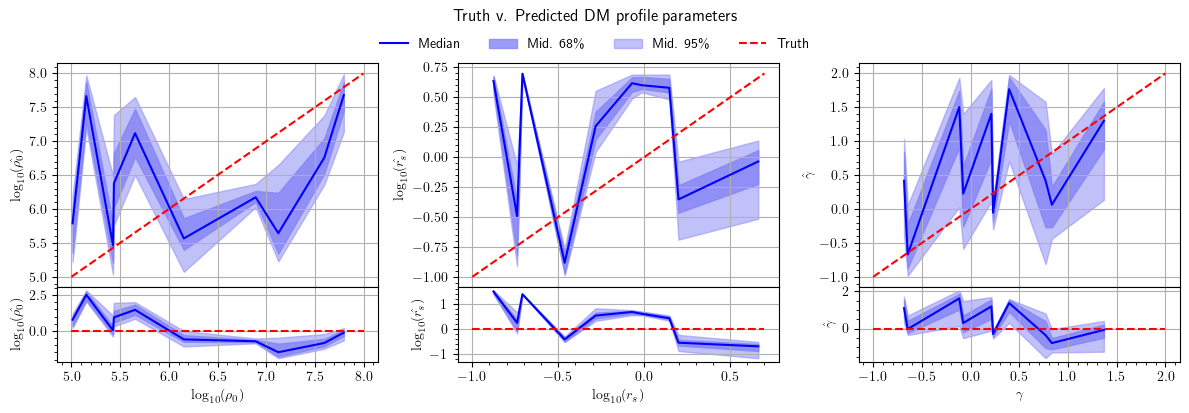

In [80]:
import matplotlib.pyplot as plt

plt.rcParams["text.usetex"] = True

fig, axs = plt.subplots(2,3, figsize=(12,4), sharex="col", gridspec_kw={'hspace': 0,
                                                                        'height_ratios': [3, 1]})

x_titles = ["$\log_{10}(\\rho _0)$", "$\log_{10}(r_s)$", "$\gamma$"]
y_titles = ["$\log_{10}(\hat{\\rho _0})$", "$\log_{10}(\hat{r_s})$", "$\hat \gamma$"]

dom_min = [5, -1, -1, 0.2, 0.5]
dom_max = [8, 0.7, 2, 1, 2]

# Top plots
for i, ax in enumerate(axs[0, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    # Median
    sim_median = y[2][:,i][index]
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index]
    sim_84 = y[3][:,i][index]
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index]
    sim_97_5 = y[4][:,i][index]
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]

    ax.plot(true_x, true_x, color="red", linestyle = "--", label="Truth")

    # ax.set_xlabel(x_titles[i])
    ax.set_ylabel(y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)

# bottom plots
bottom_y_titles = ["$\Delta \log_{10}(\\rho _0)$", "$\Delta \log_{10}(r_s)$", "$\Delta \gamma$"]
for i, ax in enumerate(axs[1, :]):
    index = np.argsort(x[:,i])
    truth = x[:,i][index]
    # Median
    sim_median = y[2][:,i][index] - truth
    ax.plot(truth, sim_median, color="blue", label="Median")

    # 68-84
    sim_16 = y[1][:,i][index] - truth
    sim_84 = y[3][:,i][index] - truth
    ax.fill_between(truth, sim_16, sim_84, color=(133 / 256,133/256,247/256, 0.8), label="Mid. 68\%")
    

    # 2.5-97.5
    sim_2_5 = y[0][:,i][index] - truth
    sim_97_5 = y[4][:,i][index] - truth
    ax.fill_between(truth, sim_2_5, sim_97_5, color=(133 / 256,133/256,247/256, 0.5), label="Mid. 95\%")

    # Truth
    true_x = [dom_min[i], dom_max[i]]
    true_y = [0,0]

    ax.plot(true_x, true_y, color="red", linestyle = "--", label="Truth")

    ax.set_xlabel(x_titles[i])
    ax.set_ylabel(y_titles[i])
    
    ax.minorticks_on()
    ax.grid(True)



fig.suptitle("Truth v. Predicted DM profile parameters", y=1.02)

handles, labels = axs[0,0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.98)

)


plt.tight_layout()
plt.show()